In [ ]:
import pandas as pd
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Data/raw_data/'

df_alarms = pd.read_csv(path + 'alarms-merged.csv', sep=';')
df_weather = pd.read_csv(path + 'all_weather_by_hour_2023-2026_v1.csv', sep=',')
df_regions = pd.read_csv(path + 'regions.csv', sep=',')

**PREPARE WEATHER**

In [ ]:
df_weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,...,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [ ]:
df_weather.shape

(808944, 65)

In [ ]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 808944 entries, 0 to 808943
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         808944 non-null  float64
 1   city_longitude        808944 non-null  float64
 2   city_resolvedAddress  808944 non-null  object 
 3   city_address          808944 non-null  object 
 4   city_timezone         808944 non-null  object 
 5   city_tzoffset         808944 non-null  float64
 6   day_datetime          808944 non-null  object 
 7   day_datetimeEpoch     808944 non-null  int64  
 8   day_tempmax           808944 non-null  float64
 9   day_tempmin           808944 non-null  float64
 10  day_temp              808944 non-null  float64
 11  day_feelslikemax      808944 non-null  float64
 12  day_feelslikemin      808944 non-null  float64
 13  day_feelslike         808944 non-null  float64
 14  day_dew               808944 non-null  float64
 15  

In [ ]:
df_weather['day_datetime'] = pd.to_datetime(df_weather['day_datetime'], format='%Y-%m-%d')
df_weather['hour_datetime'] = pd.to_datetime(df_weather['hour_datetime'], format='%H:%M:%S')

df_weather['datetime'] = pd.to_datetime(
    df_weather['day_datetime'].astype(str) + ' ' + df_weather['hour_datetime'].dt.strftime('%H:%M:%S')
)

In [ ]:
df_weather['day_datetime'].min()

Timestamp('2022-02-24 00:00:00')

In [ ]:
df_weather['day_datetime'].max()

Timestamp('2026-03-16 00:00:00')

In [ ]:
df_weather['city_address'].nunique()

23

In [ ]:
df_weather['datetime'].dtype

dtype('<M8[ns]')

In [ ]:
df_weather['city_tzoffset'].unique()

array([2.])

In [ ]:
sorted(df_weather['city_address'].unique())

['Cherkasy,Ukraine',
 'Chernihiv,Ukraine',
 'Chernivtsi,Ukraine',
 'Dnipro,Ukraine',
 'Donetsk,Ukraine',
 'Ivano-Frankivsk,Ukraine',
 'Kharkiv,Ukraine',
 'Kherson,Ukraine',
 'Khmelnytskyi,Ukraine',
 'Kropyvnytskyi,Ukraine',
 'Kyiv,Ukraine',
 'Lutsk,Ukraine',
 'Lviv,Ukraine',
 'Mykolaiv,Ukraine',
 'Odesa,Ukraine',
 'Poltava,Ukraine',
 'Rivne,Ukraine',
 'Sumy,Ukraine',
 'Ternopil,Ukraine',
 'Uzhgorod,Ukraine',
 'Vinnytsia,Ukraine',
 'Zaporozhye,Ukraine',
 'Zhytomyr,Ukraine']

In [ ]:
cols_to_drop = ['city_tzoffset', 'city_timezone', 'city_resolvedAddress',
                'day_datetimeEpoch', 'hour_datetimeEpoch',
                'day_sunrise', 'day_sunset', 'day_sunriseEpoch', 'day_sunsetEpoch',
                'day_conditions', 'day_description', 'day_icon', 'day_source',
                'day_stations', 'hour_conditions', 'hour_icon', 'hour_source', 'hour_stations']
df_weather = df_weather.drop(columns=cols_to_drop, errors='ignore')

df_weather.shape

(808944, 48)

In [ ]:
df_weather.columns.tolist()

['city_latitude',
 'city_longitude',
 'city_address',
 'day_datetime',
 'day_tempmax',
 'day_tempmin',
 'day_temp',
 'day_feelslikemax',
 'day_feelslikemin',
 'day_feelslike',
 'day_dew',
 'day_humidity',
 'day_precip',
 'day_precipprob',
 'day_precipcover',
 'day_snow',
 'day_snowdepth',
 'day_windgust',
 'day_windspeed',
 'day_winddir',
 'day_pressure',
 'day_cloudcover',
 'day_visibility',
 'day_solarradiation',
 'day_solarenergy',
 'day_uvindex',
 'day_moonphase',
 'day_preciptype',
 'hour_datetime',
 'hour_temp',
 'hour_feelslike',
 'hour_humidity',
 'hour_dew',
 'hour_precip',
 'hour_precipprob',
 'hour_snow',
 'hour_snowdepth',
 'hour_preciptype',
 'hour_windgust',
 'hour_windspeed',
 'hour_winddir',
 'hour_pressure',
 'hour_visibility',
 'hour_cloudcover',
 'hour_solarradiation',
 'hour_solarenergy',
 'hour_uvindex',
 'datetime']

In [ ]:
cols_to_drop2 = [col for col in df_weather.columns if col.startswith('day_')] + ['hour_preciptype']

df_weather = df_weather.drop(columns=cols_to_drop2, errors='ignore')
df_weather.shape

(808944, 22)

In [ ]:
# For removing temperature anomalies based on records
# Min: -41.9°C (Luhansk, 1935), Max: +42.0°C (Luhansk, 2010)

temp_cols = ['hour_temp', 'hour_feelslike', 'hour_dew']
for col in temp_cols:
    anomalies = df_weather[(df_weather[col] < -42) | (df_weather[col] > 42)]
    print(f"{col}: {len(anomalies)} anomalies")
    df_weather = df_weather[(df_weather[col] >= -42) & (df_weather[col] <= 42)]

df_weather.shape

hour_temp: 2 anomalies
hour_feelslike: 2 anomalies
hour_dew: 0 anomalies


(808940, 22)

In [ ]:
missing = df_weather.isnull().sum()
missing = missing[missing > 0]

print(missing)
print(f"\nTotal missing: {df_weather.isnull().sum().sum()}")

hour_precip               102
hour_visibility        407239
hour_solarradiation      7460
hour_solarenergy        90385
hour_uvindex             7460
dtype: int64

Total missing: 512646


In [ ]:
df_weather['city'] = df_weather['city_address'].str.replace(',Ukraine', '')
df_weather = df_weather.merge(
    df_regions[['center_city_en', 'region_id', 'region']],
    left_on='city',
    right_on='center_city_en',
    how='left'
)

df_weather['region_id'].isna().sum()

np.int64(0)

In [ ]:
df_weather[['city', 'region_id', 'region']].drop_duplicates()

,city,region_id,region
0,Lutsk,3,Волинська
7944,Kropyvnytskyi,11,Кіровоградська
15888,Dnipro,4,Дніпропетровська
23832,Kyiv,10,Київська
31776,Kherson,21,Херсонська
39720,Chernivtsi,24,Чернівецька
47664,Chernihiv,25,Чернігівська
55608,Odesa,15,Одеська
63552,Mykolaiv,14,Миколаївська
71496,Kharkiv,20,Харківська


In [ ]:
df_weather = df_weather.drop(columns=['city', 'center_city_en'], errors='ignore')

df_weather.columns.tolist()

['city_latitude',
 'city_longitude',
 'city_address',
 'hour_datetime',
 'hour_temp',
 'hour_feelslike',
 'hour_humidity',
 'hour_dew',
 'hour_precip',
 'hour_precipprob',
 'hour_snow',
 'hour_snowdepth',
 'hour_windgust',
 'hour_windspeed',
 'hour_winddir',
 'hour_pressure',
 'hour_visibility',
 'hour_cloudcover',
 'hour_solarradiation',
 'hour_solarenergy',
 'hour_uvindex',
 'datetime',
 'region_id',
 'region']

In [ ]:
df_weather = df_weather.drop(columns=['hour_datetime'], errors='ignore')

In [ ]:
sorted(df_weather['region_id'].unique())

[np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25)]

In [ ]:
print("region_id=1:", df_weather[df_weather['region_id'] == 1]['region'].unique())
print("region_id=12:", df_weather[df_weather['region_id'] == 12]['region'].unique())

region_id=1: []
region_id=12: []


In [ ]:
df_weather['hour'] = df_weather['datetime'].dt.hour
df_weather['month'] = df_weather['datetime'].dt.month
df_weather['season'] = df_weather['month'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
})
df_weather['is_weekend'] = df_weather['datetime'].dt.dayofweek.isin([5, 6]).astype(int)

In [ ]:
df_weather[['datetime', 'hour', 'month', 'season', 'is_weekend']].head(5)

,datetime,hour,month,season,is_weekend
0,2022-02-24 00:00:00,0,2,winter,0
1,2022-02-24 01:00:00,1,2,winter,0
2,2022-02-24 02:00:00,2,2,winter,0
3,2022-02-24 03:00:00,3,2,winter,0
4,2022-02-24 04:00:00,4,2,winter,0


In [ ]:
# For checking which rows have missing values
missing_rows = df_weather[df_weather.isnull().any(axis=1)]

df_weather.isnull().sum()[df_weather.isnull().sum() > 0]

,0
hour_precip,102
hour_visibility,407239
hour_solarradiation,7460
hour_solarenergy,90385
hour_uvindex,7460


In [ ]:
# For checking if missing rows overlap
solar_missing = set(df_weather[df_weather['hour_solarradiation'].isna()].index)
uv_missing = set(df_weather[df_weather['hour_uvindex'].isna()].index)

len(solar_missing & uv_missing)

7460

In [ ]:
# For dropping visibility (50% missing - too many to fill)
df_weather = df_weather.drop(columns=['hour_visibility'], errors='ignore')

# For precipping with 0 (no precipitation)
df_weather['hour_precip'] = df_weather['hour_precip'].fillna(0)

# For filling solarenergy with ffill (cumulative value)
df_weather['hour_solarenergy'] = df_weather.groupby('city_address')['hour_solarenergy'].ffill().bfill()

# For filling solarradiation and uvindex with mean by hour and month
for col in ['hour_solarradiation', 'hour_uvindex']:
    df_weather[col] = df_weather.groupby(['city_address', 'month', 'hour'])[col].transform(
        lambda x: x.fillna(x.mean())
    )

df_weather.isnull().sum().sum()

np.int64(0)

In [ ]:
processed_path = '/content/drive/MyDrive/Data/processed_data/'

df_weather.to_csv(processed_path + 'weather_clean.csv', index=False)

**Visualization**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

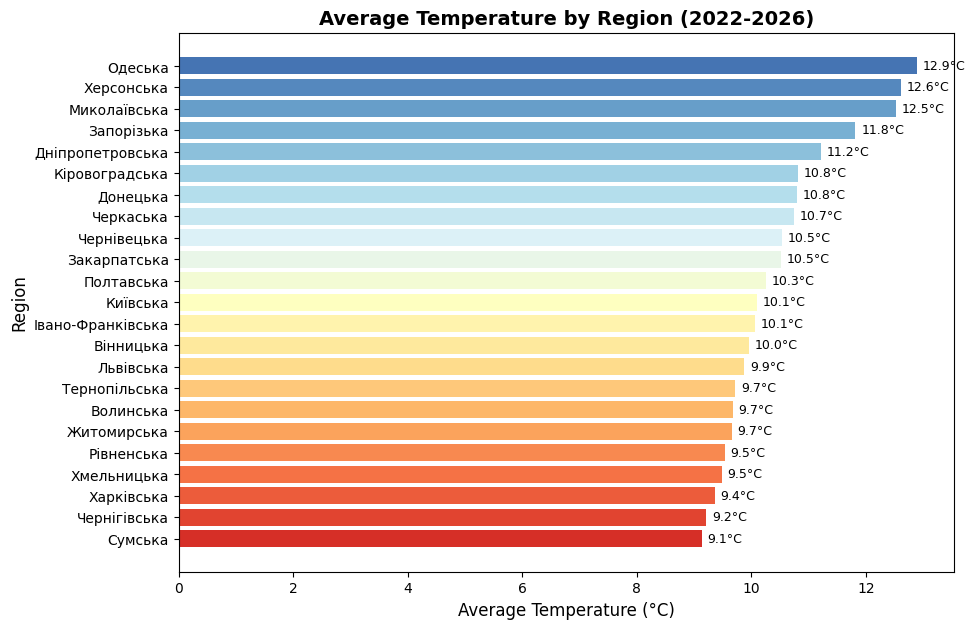

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

region_temp = df_weather.groupby('region')['hour_temp'].mean().sort_values(ascending=True)
colors = plt.cm.RdYlBu(np.linspace(0.1, 0.9, len(region_temp)))
bars = ax.barh(region_temp.index, region_temp.values, color=colors)

ax.set_title('Average Temperature by Region (2022-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Temperature (°C)', fontsize=12)
ax.set_ylabel('Region', fontsize=12)

for bar, val in zip(bars, region_temp.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}°C', va='center', fontsize=9)



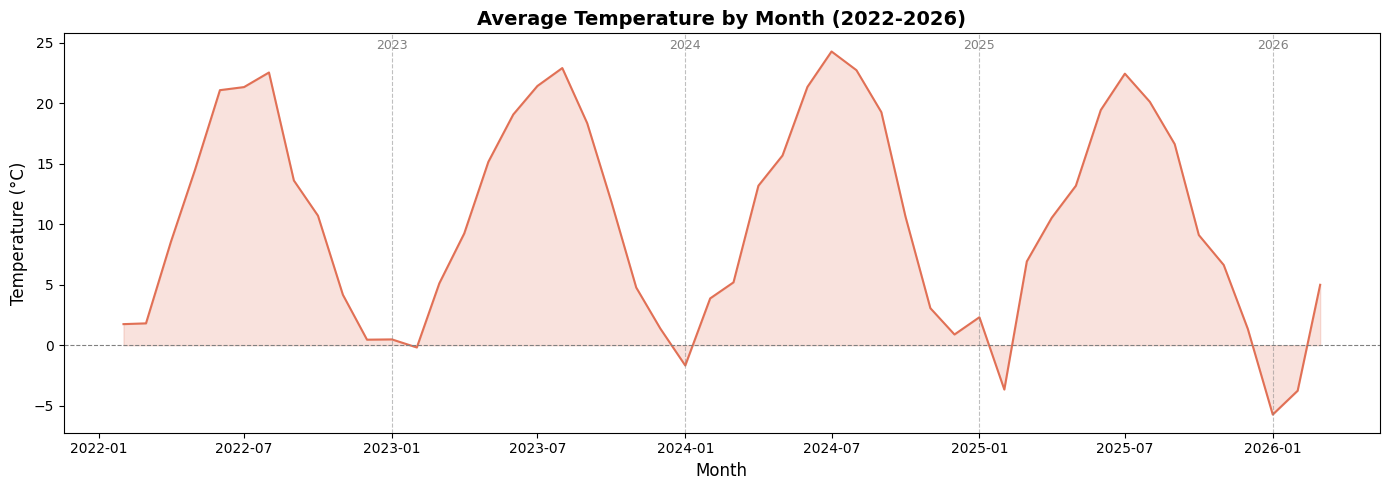

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

monthly_temp = df_weather.groupby(
    df_weather['datetime'].dt.to_period('M')
)['hour_temp'].mean().reset_index()
monthly_temp.columns = ['period', 'temp']
monthly_temp['date'] = monthly_temp['period'].dt.to_timestamp()

ax.plot(monthly_temp['date'], monthly_temp['temp'], color='#e17055', linewidth=1.5)
ax.fill_between(monthly_temp['date'], monthly_temp['temp'], alpha=0.2, color='#e17055')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for year in [2023, 2024, 2025, 2026]:
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1]*0.95, str(year),
            ha='center', fontsize=9, color='gray')

ax.set_title('Average Temperature by Month (2022-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)

plt.tight_layout()
plt.savefig('weather_temp_trend.png', dpi=150, bbox_inches='tight')


Text(0.5, 1.0, 'Weather Features Correlation Matrix')

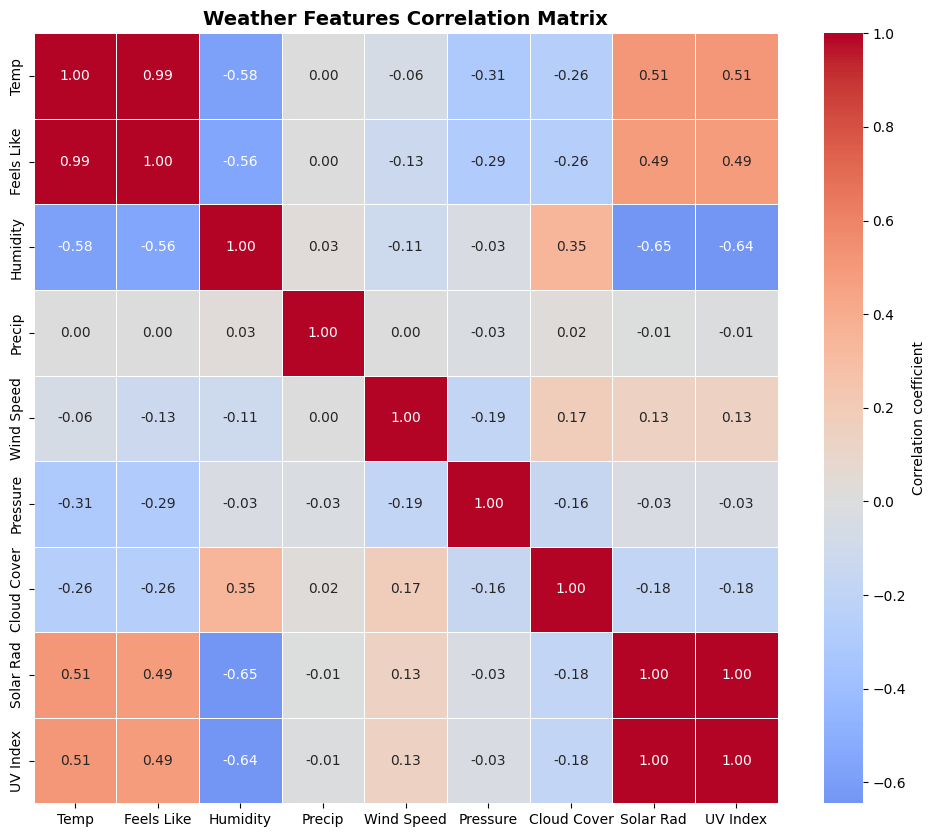

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

weather_cols = ['hour_temp', 'hour_feelslike', 'hour_humidity',
                'hour_precip', 'hour_windspeed', 'hour_pressure',
                'hour_cloudcover', 'hour_solarradiation', 'hour_uvindex']

corr = df_weather[weather_cols].corr()

labels = ['Temp', 'Feels Like', 'Humidity', 'Precip',
          'Wind Speed', 'Pressure', 'Cloud Cover', 'Solar Rad', 'UV Index']

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Correlation coefficient'})

ax.set_title('Weather Features Correlation Matrix', fontsize=14, fontweight='bold')



**PREPARE ALARMS**

In [ ]:
df_alarms.head()

,id,merged_id,region_id,region_title,region_city,all_region,start,end,original_alarms
0,35427,8a51c79fd40b6fc9be68e7aa3601e602,12,Львівська область,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,"[""52432""]"
1,71822,a6fa45504565dc0928efc8807db66487,23,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,"[""53292""]"
2,1746,c0ff722f9fac93e89919c7b09695dda5,3,Вінницька область,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,"[""52080""]"
3,55540,066e25a0712b306a9b95230f6ec4a051,19,Харківська область,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,"[""52857""]"
4,54611,73dcb24720672b203e7c6763639860f3,18,Тернопільська область,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,"[""52700""]"


In [ ]:
df_alarms.shape

(76232, 9)

In [ ]:
df_alarms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76232 entries, 0 to 76231
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               76232 non-null  int64 
 1   merged_id        76232 non-null  object
 2   region_id        76232 non-null  int64 
 3   region_title     76232 non-null  object
 4   region_city      76232 non-null  object
 5   all_region       76232 non-null  int64 
 6   start            76232 non-null  object
 7   end              76232 non-null  object
 8   original_alarms  76232 non-null  object
dtypes: int64(3), object(6)
memory usage: 5.2+ MB


In [ ]:
df_alarms['start'] = pd.to_datetime(df_alarms['start'])
df_alarms['end'] = pd.to_datetime(df_alarms['end'])

df_alarms['duration_min'] = (df_alarms['end'] - df_alarms['start']).dt.total_seconds() / 60

df_alarms['duration_min'].describe()

,duration_min
count,76232.000000
mean,90.888377
std,142.248317
min,-781.700000
25%,26.666667
50%,42.783333
75%,100.500000
max,5265.200000


In [ ]:
(df_alarms['duration_min'] < 0).sum()

np.int64(2)

In [ ]:
df_alarms = df_alarms[df_alarms['duration_min'] > 0]

df_alarms.shape

(76230, 10)

In [ ]:
df_alarms[df_alarms['duration_min'] > 24*60][['region_title', 'start', 'end', 'duration_min']]

,region_title,start,end,duration_min
42768,Харківська область,2024-07-07 14:27:23,2024-07-09 03:15:08,2207.750000
43644,Харківська область,2024-07-20 08:47:05,2024-07-21 23:04:00,2296.916667
43799,Харківська область,2024-07-23 18:31:33,2024-07-25 21:02:51,3031.300000
43933,Харківська область,2024-07-26 00:54:28,2024-07-27 01:56:32,1502.066667
44549,Сумська область,2024-08-06 11:10:26,2024-08-07 15:13:04,1682.633333
...,...,...,...,...
75170,Донецька область,2026-02-28 01:14:43,2026-03-01 18:47:00,2492.283333
75176,Харківська область,2026-02-28 05:54:26,2026-03-01 18:47:26,2213.000000
75864,Донецька область,2026-03-11 20:34:09,2026-03-13 17:47:44,2713.583333
75991,Дніпропетровська область,2026-03-13 14:58:51,2026-03-14 20:20:00,1761.150000


In [ ]:
df_alarms['region_id'].nunique()

23

In [ ]:
sorted(df_alarms['region_title'].unique())

['Івано-Франківська область',
 'Волинська область',
 'Вінницька область',
 'Дніпропетровська область',
 'Донецька область',
 'Житомирська область',
 'Закарпатська область',
 'Запорізька область',
 'Київська область',
 'Кіровоградська область',
 'Львівська область',
 'Миколаївська область',
 'Одеська область',
 'Полтавська область',
 'Рівненська область',
 'Сумська область',
 'Тернопільська область',
 'Харківська область',
 'Херсонська область',
 'Хмельницька область',
 'Черкаська область',
 'Чернівецька область',
 'Чернігівська область']

In [ ]:
df_alarms['start'] = pd.to_datetime(df_alarms['start']).dt.tz_localize(None)
df_alarms['end'] = pd.to_datetime(df_alarms['end']).dt.tz_localize(None)

df_alarms['start'].dtype

dtype('<M8[ns]')

In [ ]:
df_alarms['region_name'] = df_alarms['region_title'].str.replace(' область', '')
df_alarms = df_alarms.merge(
    df_regions[['region', 'region_id']],
    left_on='region_name',
    right_on='region',
    how='left',
    suffixes=('_old', '')
)
df_alarms = df_alarms.drop(columns=['region_id_old', 'region_name', 'region'], errors='ignore')

In [ ]:
# For expanding each alarm to all hours it covers
def expand_alarm_hours(row):
    hours = pd.date_range(
        start=row['start'].floor('h'),
        end=row['end'].floor('h'),
        freq='h'
    )
    return pd.DataFrame({
        'datetime': hours,
        'region_id': row['region_id'],
        'region_title': row['region_title'],
        'alarm': 1
    })

df_alarms_hourly = pd.concat(
    df_alarms.apply(expand_alarm_hours, axis=1).tolist(),
    ignore_index=True
) # for collecting all alerts into a single dataframe

df_alarms_hourly.shape

(191948, 4)

In [ ]:
df_alarms_hourly.head()

,datetime,region_id,region_title,alarm
0,2022-02-24 07:00:00,12,Львівська область,1
1,2022-02-24 08:00:00,12,Львівська область,1
2,2022-02-24 09:00:00,12,Львівська область,1
3,2022-02-24 14:00:00,23,Чернігівська область,1
4,2022-02-24 15:00:00,23,Чернігівська область,1


In [ ]:
df_alarms_hourly['alarm'].unique()

array([1])

In [ ]:
df_alarms_hourly['datetime'].min()

Timestamp('2022-02-24 07:00:00')

In [ ]:
df_alarms_hourly['datetime'].max()

Timestamp('2026-03-17 07:00:00')

In [ ]:
sorted(df_alarms_hourly['region_id'].unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24)]

In [ ]:
# For checking region_id mapping in df_regions
print(df_regions[['region_id', 'region', 'center_city_en']].sort_values('region_id').to_string())

# For checking region_id in alarms
print(df_alarms[['region_id', 'region_title']].drop_duplicates().sort_values('region_id').to_string())

    region_id             region   center_city_en
0           1            АР Крим       Simferopol
1           2          Вінницька        Vinnytsia
2           3          Волинська            Lutsk
3           4   Дніпропетровська           Dnipro
4           5           Донецька          Donetsk
5           6        Житомирська         Zhytomyr
6           7       Закарпатська         Uzhgorod
7           8         Запорізька       Zaporozhye
8           9  Івано-Франківська  Ivano-Frankivsk
9          10           Київська             Kyiv
10         11     Кіровоградська    Kropyvnytskyi
11         12          Луганська          Luhansk
12         13          Львівська             Lviv
13         14       Миколаївська         Mykolaiv
14         15            Одеська            Odesa
15         16         Полтавська          Poltava
16         17         Рівненська            Rivne
17         18            Сумська             Sumy
18         19      Тернопільська         Ternopil


In [ ]:
df_alarms_hourly['region_name'] = df_alarms_hourly['region_title'].str.replace(' область', '')

print(df_alarms_hourly['region_name'].unique()[:5])
print(df_regions['region'].unique()[:5])

['Львівська' 'Чернігівська' 'Вінницька' 'Харківська' 'Тернопільська']
['АР Крим' 'Вінницька' 'Волинська' 'Дніпропетровська' 'Донецька']


In [ ]:
sorted(df_alarms_hourly['region_id'].unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24)]

In [ ]:
print("region_id=1:", df_alarms_hourly[df_alarms_hourly['region_id'] == 1]['region_title'].unique())
print("region_id=12:", df_alarms_hourly[df_alarms_hourly['region_id'] == 12]['region_title'].unique())

region_id=1: ['Чернівецька область']
region_id=12: ['Львівська область']


In [ ]:
df_alarms_hourly = df_alarms_hourly.drop_duplicates(subset=['datetime', 'region_id'])

df_alarms_hourly.shape

(178392, 5)

In [ ]:
df_alarms_hourly['datetime'] = pd.to_datetime(df_alarms_hourly['datetime'])

df_alarms_hourly.dtypes

,0
datetime,datetime64[ns]
region_id,int64
region_title,object
alarm,int64
region_name,object


In [ ]:
df_alarms_hourly.to_csv(processed_path + 'alarms_hourly.csv', index=False)

In [ ]:
print(df_alarms[['region_title', 'duration_min']].head(3))

           region_title  duration_min
0     Львівська область    129.183333
1  Чернігівська область    191.000000
2     Вінницька область     30.000000


**Visualization**

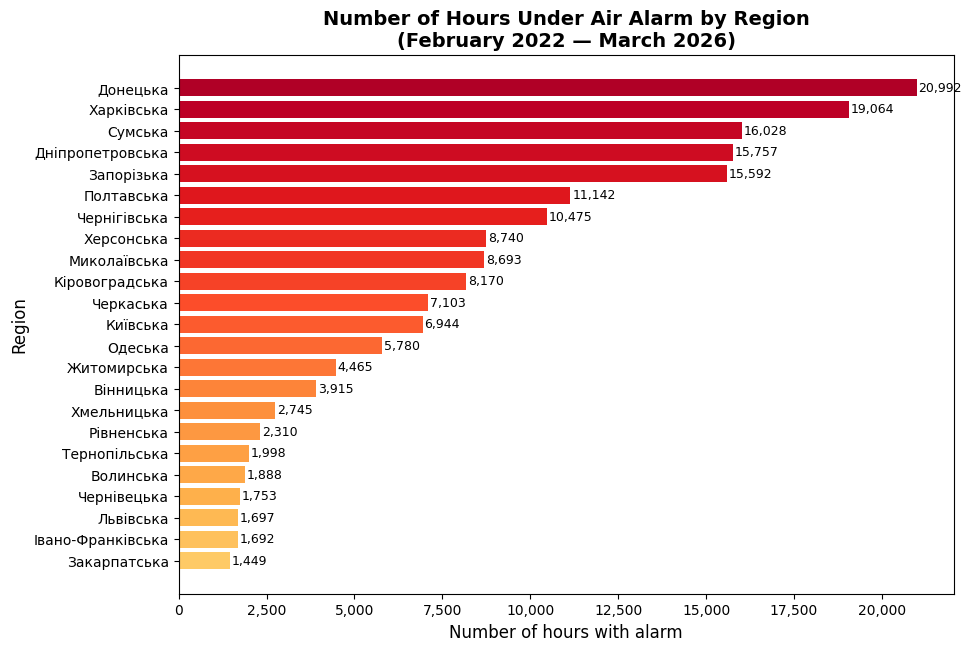

In [ ]:
df_alarms_hourly['region_short'] = df_alarms_hourly['region_title'].str.replace(' область', '')
fig, ax = plt.subplots(figsize=(10, 7))

region_counts = df_alarms_hourly.groupby('region_short').size().sort_values(ascending=True)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(region_counts)))
bars = ax.barh(region_counts.index, region_counts.values, color=colors)

ax.set_title('Number of Hours Under Air Alarm by Region\n(February 2022 — March 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of hours with alarm', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, region_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

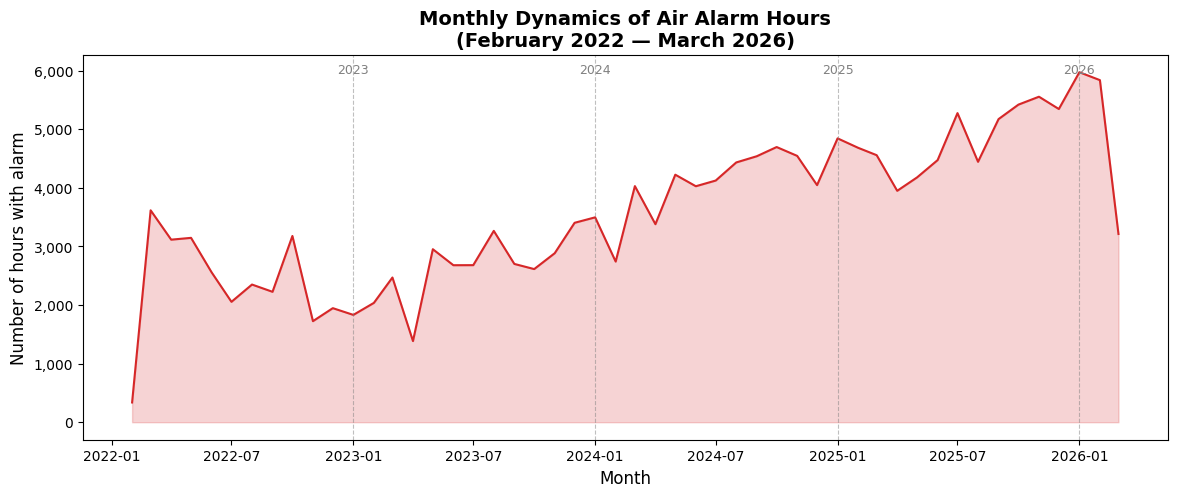

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

monthly = df_alarms_hourly.groupby(
    df_alarms_hourly['datetime'].dt.to_period('M')
).size().reset_index()
monthly.columns = ['period', 'count']
monthly['date'] = monthly['period'].dt.to_timestamp()

ax.plot(monthly['date'], monthly['count'], color='#d62728', linewidth=1.5)
ax.fill_between(monthly['date'], monthly['count'], alpha=0.2, color='#d62728')

ax.set_title('Monthly Dynamics of Air Alarm Hours\n(February 2022 — March 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of hours with alarm', fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for year in [2023, 2024, 2025, 2026]:
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1]*0.95, str(year),
            ha='center', fontsize=9, color='gray')

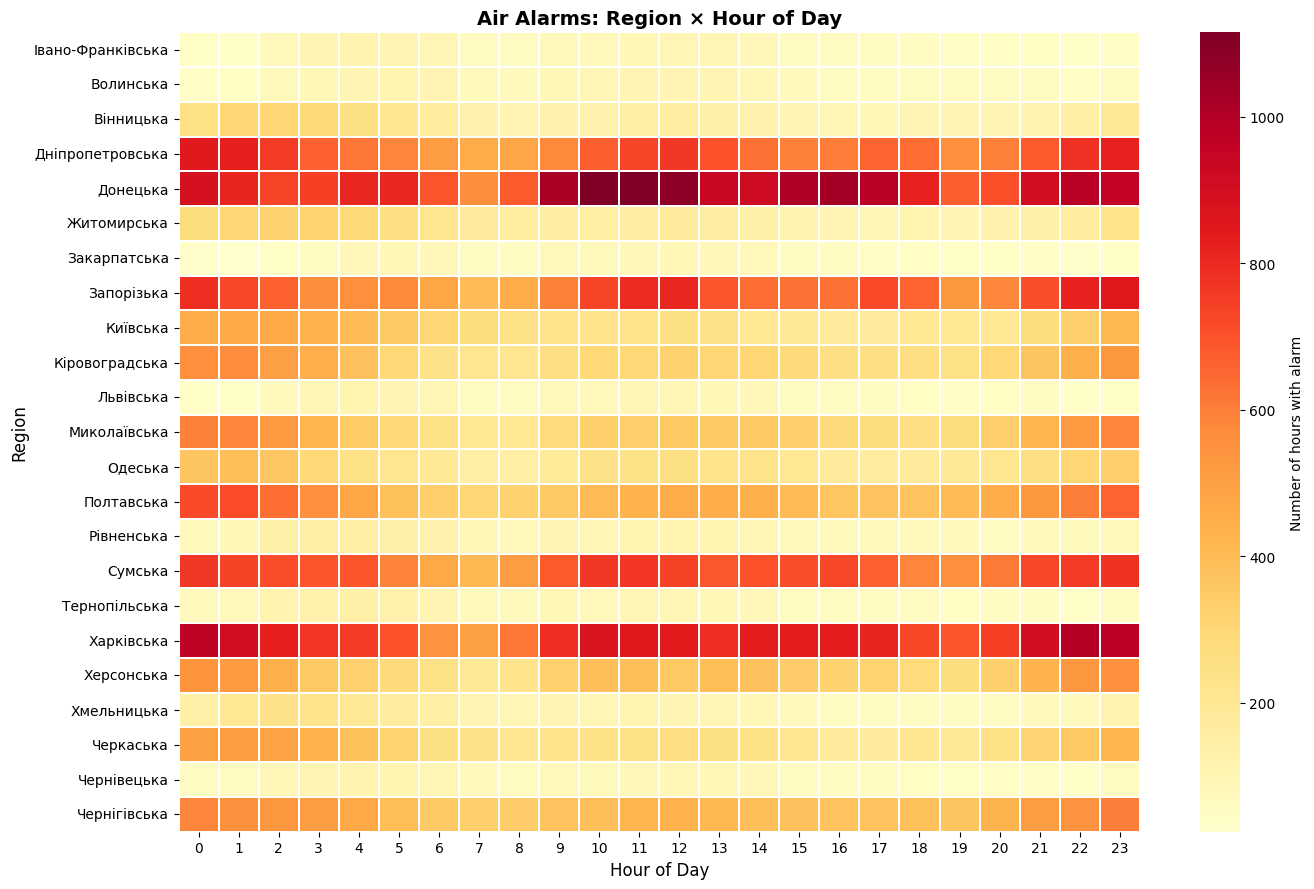

In [ ]:
df_alarms_hourly['hour'] = df_alarms_hourly['datetime'].dt.hour
df_alarms_hourly['region_short'] = df_alarms_hourly['region_title'].str.replace(' область', '')

fig, ax = plt.subplots(figsize=(14, 9))

heatmap_data = df_alarms_hourly.groupby(['region_short', 'hour']).size().unstack(fill_value=0)

sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Number of hours with alarm'})

ax.set_title('Air Alarms: Region × Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Region', fontsize=12)

plt.tight_layout()
plt.savefig('alarms_heatmap_region_hour.png', dpi=150, bbox_inches='tight')
plt.show()

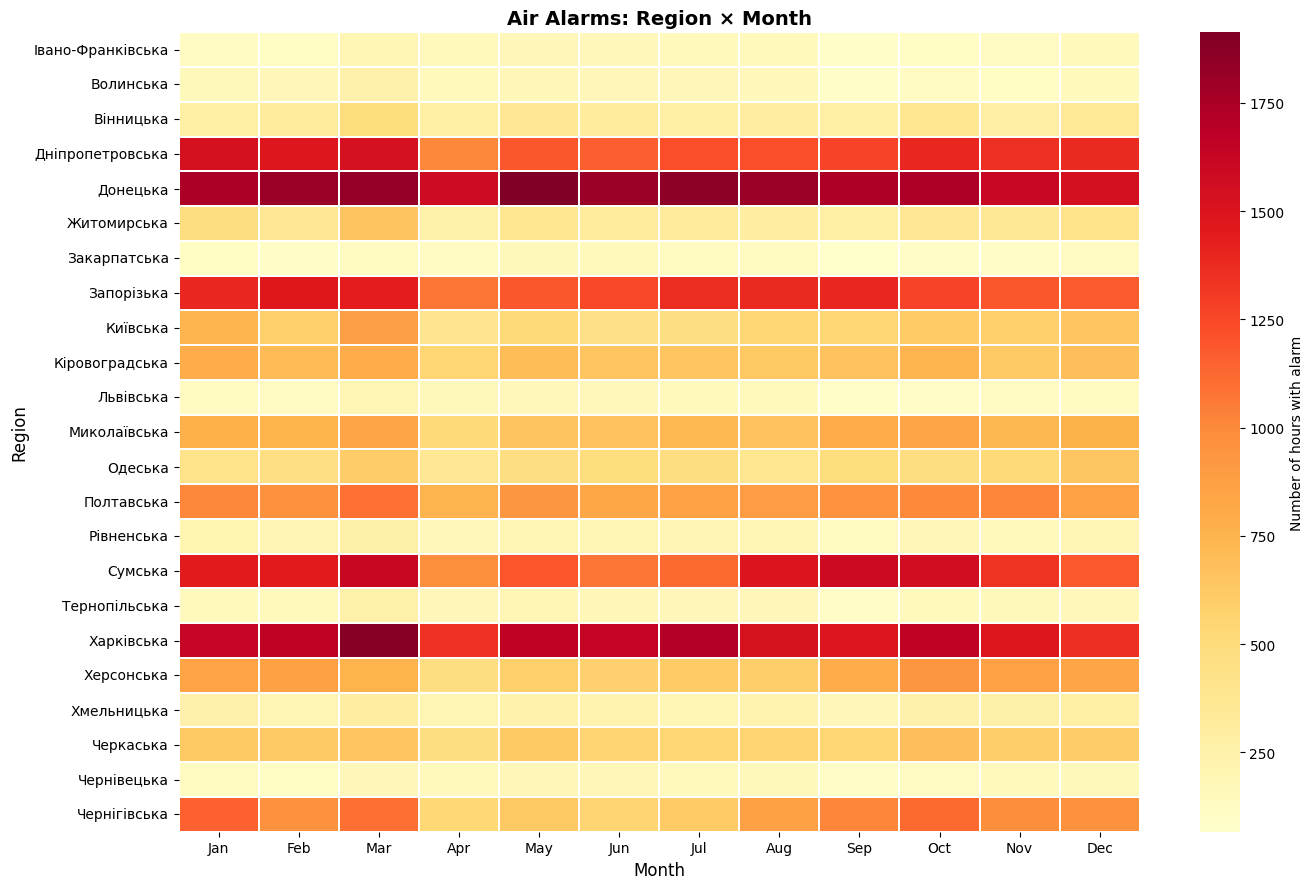

In [ ]:
df_alarms_hourly['month'] = df_alarms_hourly['datetime'].dt.month

fig, ax = plt.subplots(figsize=(14, 9))

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_month = df_alarms_hourly.groupby(
    ['region_short', 'month']
).size().unstack(fill_value=0)
heatmap_month.columns = [month_names[m-1] for m in heatmap_month.columns]

sns.heatmap(heatmap_month, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Number of hours with alarm'})

ax.set_title('Air Alarms: Region × Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Region', fontsize=12)

plt.tight_layout()
plt.savefig('alarms_heatmap_region_month.png', dpi=150, bbox_inches='tight')
plt.show()

**REGIONS**

In [ ]:
df_regions.head()

,region,center_city_ua,center_city_en,region_alt,region_id
0,АР Крим,Сімферополь,Simferopol,Крим,1
1,Вінницька,Вінниця,Vinnytsia,Вінниччина,2
2,Волинська,Луцьк,Lutsk,Волинь,3
3,Дніпропетровська,Дніпро,Dnipro,Дніпропетровщина,4
4,Донецька,Донецьк,Donetsk,Донеччина,5


In [ ]:
df_regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   region          25 non-null     object
 1   center_city_ua  25 non-null     object
 2   center_city_en  25 non-null     object
 3   region_alt      25 non-null     object
 4   region_id       25 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 1.1+ KB


In [ ]:
sorted(df_regions['center_city_en'].unique())

['Cherkasy',
 'Chernihiv',
 'Chernivtsi',
 'Dnipro',
 'Donetsk',
 'Ivano-Frankivsk',
 'Kharkiv',
 'Kherson',
 'Khmelnytskyi',
 'Kropyvnytskyi',
 'Kyiv',
 'Luhansk',
 'Lutsk',
 'Lviv',
 'Mykolaiv',
 'Odesa',
 'Poltava',
 'Rivne',
 'Simferopol',
 'Sumy',
 'Ternopil',
 'Uzhgorod',
 'Vinnytsia',
 'Zaporozhye',
 'Zhytomyr']

In [ ]:
print(df_regions[['region', 'center_city_en', 'region_id']].to_string(index=False))

           region  center_city_en  region_id
          АР Крим      Simferopol          1
        Вінницька       Vinnytsia          2
        Волинська           Lutsk          3
 Дніпропетровська          Dnipro          4
         Донецька         Donetsk          5
      Житомирська        Zhytomyr          6
     Закарпатська        Uzhgorod          7
       Запорізька      Zaporozhye          8
Івано-Франківська Ivano-Frankivsk          9
         Київська            Kyiv         10
   Кіровоградська   Kropyvnytskyi         11
        Луганська         Luhansk         12
        Львівська            Lviv         13
     Миколаївська        Mykolaiv         14
          Одеська           Odesa         15
       Полтавська         Poltava         16
       Рівненська           Rivne         17
          Сумська            Sumy         18
    Тернопільська        Ternopil         19
       Харківська         Kharkiv         20
       Херсонська         Kherson         21
      Хмел

In [ ]:
продовження візуалізацій

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from itertools import combinations
from datetime import timedelta

from statsmodels.tsa.seasonal import seasonal_decompose

from plotly.subplots import make_subplots

from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import signal

In [ ]:
# 1. Переконуємось, що start та end у правильному форматі
df_alarms['start'] = pd.to_datetime(df_alarms['start'])
df_alarms['end'] = pd.to_datetime(df_alarms['end'])

# 2. Створюємо тривалість у хвилинах (це потрібно для аналізу)
df_alarms['duration_min'] = (df_alarms['end'] - df_alarms['start']).dt.total_seconds() / 60

# 3. Видаляємо тривоги з від'ємною тривалістю
df_alarms = df_alarms[df_alarms['duration_min'] > 0]

# 4. Додаємо часові ознаки
df_alarms['start_hour'] = df_alarms['start'].dt.hour
df_alarms['start_day_of_week'] = df_alarms['start'].dt.dayofweek
df_alarms['start_month'] = df_alarms['start'].dt.month
df_alarms['start_year'] = df_alarms['start'].dt.year

# 5. Додаємо сезон (опціонально, для аналізу)
df_alarms['season'] = df_alarms['start_month'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
})

# 6. Додаємо ознаку вихідного дня (опціонально)
df_alarms['is_weekend'] = df_alarms['start_day_of_week'].isin([5, 6]).astype(int)

# Перевіряємо
print("Часові ознаки додано до df_alarms")
print(df_alarms[['start', 'duration_min', 'start_hour', 'start_day_of_week', 'start_month', 'season', 'is_weekend']].head())

Часові ознаки додано до df_alarms
                start  duration_min  start_hour  start_day_of_week  \
0 2022-02-24 07:43:17    129.183333           7                  3   
1 2022-02-24 14:00:43    191.000000          14                  3   
2 2022-02-24 15:40:42     30.000000          15                  3   
3 2022-02-24 20:11:47     48.000000          20                  3   
4 2022-02-25 01:59:36    420.716667           1                  4   

   start_month  season  is_weekend  
0            2  winter           0  
1            2  winter           0  
2            2  winter           0  
3            2  winter           0  
4            2  winter           0  


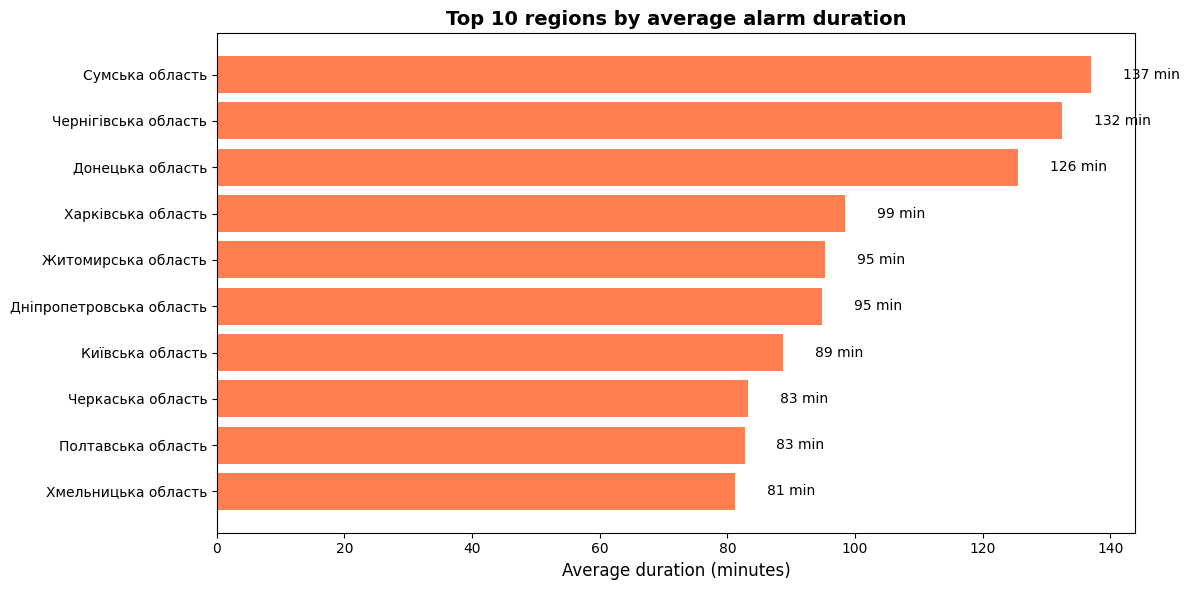

In [ ]:
region_duration = df_alarms.groupby('region_title')['duration_min'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(region_duration)), region_duration.values, color='coral')
plt.yticks(range(len(region_duration)), region_duration.index)
plt.xlabel('Average duration (minutes)', fontsize=12)
plt.title('Top 10 regions by average alarm duration', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Додаємо значення на графік
for i, v in enumerate(region_duration.values):
    plt.text(v + 5, i, f'{v:.0f} min', va='center')

plt.tight_layout()
plt.show()

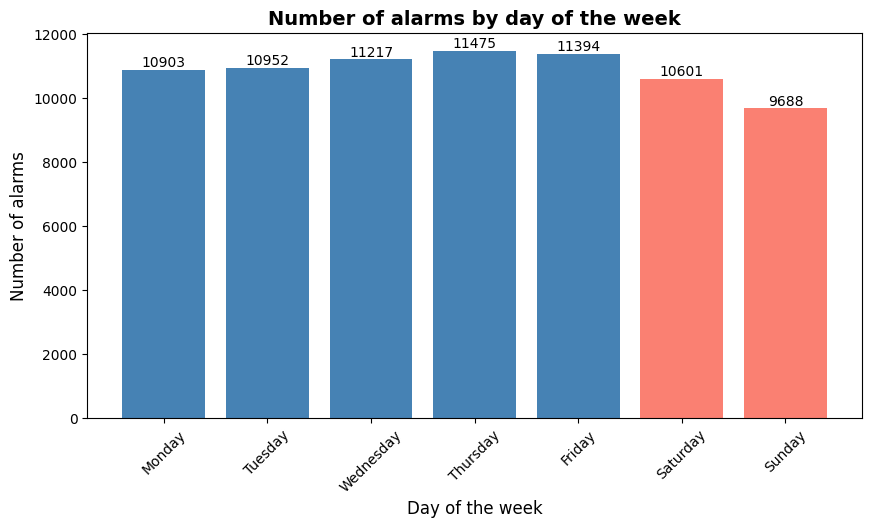

In [ ]:
plt.figure(figsize=(10, 5))

weekday_counts = df_alarms.groupby('start_day_of_week').size()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.bar(days, weekday_counts.values, color=['steelblue' if i < 5 else 'salmon' for i in range(7)])
plt.title('Number of alarms by day of the week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the week', fontsize=12)
plt.ylabel('Number of alarms', fontsize=12)
plt.xticks(rotation=45)

for i, v in enumerate(weekday_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

In [ ]:
region_coords = {
    'Вінницька область': (49.2333, 28.4667),
    'Волинська область': (50.7472, 25.3254),
    'Дніпропетровська область': (48.4647, 35.0462),
    'Донецька область': (48.0159, 37.8029),
    'Житомирська область': (50.2547, 28.6581),
    'Закарпатська область': (48.6208, 22.2879),
    'Запорізька область': (47.8388, 35.1396),
    'Івано-Франківська область': (48.9226, 24.7111),
    'Київська область': (50.4501, 30.5234),
    'Кіровоградська область': (48.5079, 32.2623),
    'Луганська область': (48.5740, 39.3078),
    'Львівська область': (49.8397, 24.0297),
    'Миколаївська область': (46.9750, 31.9946),
    'Одеська область': (46.4825, 30.7233),
    'Полтавська область': (49.5890, 34.5500),
    'Рівненська область': (50.6199, 26.2516),
    'Сумська область': (50.9077, 34.7981),
    'Тернопільська область': (49.5535, 25.5948),
    'Харківська область': (49.9935, 36.2304),
    'Херсонська область': (46.6354, 32.6169),
    'Хмельницька область': (49.4229, 26.9974),
    'Черкаська область': (49.4444, 32.0598),
    'Чернівецька область': (48.2921, 25.9358),
    'Чернігівська область': (51.4982, 31.2893),
}

alarms_count = df_alarms.groupby('region_title').size().reset_index(name='alarm_count')
alarms_count['lat'] = alarms_count['region_title'].map(lambda x: region_coords.get(x, (None, None))[0])
alarms_count['lon'] = alarms_count['region_title'].map(lambda x: region_coords.get(x, (None, None))[1])
alarms_count = alarms_count.dropna()


hot_colorscale = [
    [0, '#ffff99'],
    [0.3, '#ffcc33'],
    [0.5, '#ff9933'],
    [0.7, '#ff6633'],
    [0.85, '#ff3333'],
    [1.0, '#990000']
]


fig = px.scatter_geo(
    alarms_count,
    lat='lat',
    lon='lon',
    size='alarm_count',
    color='alarm_count',
    hover_name='region_title',
    text='region_title',
    size_max=60,
    color_continuous_scale=hot_colorscale,
    title='Number of air alerts by regions of Ukraine (2022-2026)',
    labels={'alarm_count': 'Number of alarms'}
)


fig.update_geos(
    visible=True,
    resolution=50,
    scope='europe',
    lonaxis_range=[22, 41],
    lataxis_range=[44, 53],
    showcountries=True,
    countrycolor='black',
    showland=True,
    landcolor='#f0f0f0'
)

fig.update_traces(
    marker=dict(
        line=dict(width=1.5, color='black'),
        opacity=0.85
    ),
    textfont=dict(size=9, color='black', family='Arial'),
    textposition='top center'
)


fig.update_coloraxes(
    colorbar=dict(
        title="Number of alarms",
        title_font=dict(size=12),
        tickfont=dict(size=10)
    )
)

fig.update_layout(
    height=700,
    width=1000,
    margin={"r":0, "t":50, "l":0, "b":0},
    title_font=dict(size=16, color='darkred'),
    paper_bgcolor='white'
)

fig.show()

In [ ]:
region_positions = {
    'Волинська область': (1, 5),      # північний захід
    'Рівненська область': (2, 5),
    'Житомирська область': (3, 5),
    'Київська область': (4, 5),
    'Чернігівська область': (5, 5),
    'Сумська область': (6, 5),        # північний схід

    'Львівська область': (1, 4),
    'Тернопільська область': (2, 4),
    'Хмельницька область': (3, 4),
    'Черкаська область': (4, 4),
    'Полтавська область': (5, 4),
    'Харківська область': (6, 4),

    'Закарпатська область': (1, 3),
    'Івано-Франківська область': (2, 3),
    'Чернівецька область': (3, 3),
    'Вінницька область': (4, 3),
    'Кіровоградська область': (5, 3),
    'Дніпропетровська область': (6, 3),

    'Одеська область': (2, 2),
    'Миколаївська область': (3, 2),
    'Запорізька область': (4, 2),
    'Донецька область': (5, 2),
    'Луганська область': (6, 2),

    'Херсонська область': (3, 1),
    'АР Крим': (4, 0),
}

alarms_count = df_alarms.groupby('region_title').size().reset_index(name='count')


alarms_count['x'] = alarms_count['region_title'].map(lambda x: region_positions.get(x, (None, None))[0])
alarms_count['y'] = alarms_count['region_title'].map(lambda x: region_positions.get(x, (None, None))[1])
alarms_count = alarms_count.dropna()


max_count = alarms_count['count'].max()


fig = go.Figure()


for _, row in alarms_count.iterrows():
    # Інтенсивність кольору від світло-червоного до темно-червоного
    intensity = row['count'] / max_count
    color = f'rgba(200, {int(50 + 100*(1-intensity))}, {int(50 + 100*(1-intensity))}, 0.9)'

    fig.add_shape(type="rect", x0=row['x'] - 0.4, x1=row['x'] + 0.4, y0=row['y'] - 0.3, y1=row['y'] + 0.3, fillcolor=color, line=dict(color='black', width=1), name=row['region_title'])

    fig.add_annotation(x=row['x'], y=row['y'], text=row['region_title'].replace(' region', ''), showarrow=False, font=dict(size=9), yshift=10)


    fig.add_annotation(x=row['x'], y=row['y'], text=f"{row['count']:,}", showarrow=False, font=dict(size=8, color='darkred'), yshift=-10)

fig.update_layout(title='Number of air alerts by regions of Ukraine (schematic map)', xaxis=dict(showgrid=False, showticklabels=False, range=[0, 7]), yaxis=dict( showgrid=False,
        showticklabels=False,
        range=[-0.5, 5.5],
        scaleanchor="x",
        scaleratio=1
    ),
    height=1000,
    width=1300,
    plot_bgcolor='#f5f5f5'
)

fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from statsmodels.tsa.seasonal import seasonal_decompose

kyiv_weather = df_weather[df_weather['city_address'] == 'Kyiv,Ukraine'].copy()
kyiv_weather = kyiv_weather.set_index('datetime')
kyiv_weather = kyiv_weather.resample('D').agg({
    'hour_temp': 'mean',
    'hour_humidity': 'mean',
    'hour_pressure': 'mean'
}).dropna()

print(f"Дані Києва: {len(kyiv_weather)} днів")

decomposition_temp = seasonal_decompose(kyiv_weather['hour_temp'], model='additive', period=365)


fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=(
        '<b>Original series (average daily temperature)</b>',
        '<b>Trend (long-term dynamics)</b>',
        '<b>Seasonal component (annual cycle)</b>',
        '<b>Residuals (random fluctuations)</b>'
    ),
    vertical_spacing=0.08,
    row_heights=[0.3, 0.2, 0.25, 0.25]
)


fig.add_trace(
    go.Scatter(
        x=kyiv_weather.index,
        y=decomposition_temp.observed,
        mode='lines',
        name='Original',
        line=dict(color='#2c3e50', width=1.5),
        fill='tozeroy',
        fillcolor='rgba(44, 62, 80, 0.1)'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=kyiv_weather.index,
        y=decomposition_temp.trend,
        mode='lines',
        name='Trend',
        line=dict(color='#e67e22', width=3),
        fill='tozeroy',
        fillcolor='rgba(230, 126, 34, 0.1)'
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=kyiv_weather.index,
        y=decomposition_temp.seasonal,
        mode='lines',
        name='Seasonality',
        line=dict(color='#27ae60', width=2),
        fill='tozeroy',
        fillcolor='rgba(39, 174, 96, 0.2)'
    ),
    row=3, col=1
)


fig.add_trace(
    go.Scatter(
        x=kyiv_weather.index,
        y=decomposition_temp.resid,
        mode='markers',
        name='Residuals',
        marker=dict(size=3, color='#c0392b', opacity=0.6, symbol='circle')
    ),
    row=4, col=1
)

fig.update_layout(
    title=dict(
        text='<b>Decomposition of the temperature series (Kyiv, 2022-2026)</b><br>'
             '<span style="font-size:12px">Additive decomposition | Період = 365 днів</span>',
        x=0.5,
        font=dict(size=16)
    ),
    height=900,
    hovermode='x unified',
    showlegend=False
)

fig.update_xaxes(title_text="Date", row=4, col=1)
fig.update_yaxes(title_text="°C", row=1, col=1)
fig.update_yaxes(title_text="°C (trend)", row=2, col=1)
fig.update_yaxes(title_text="°C (season)", row=3, col=1)
fig.update_yaxes(title_text="°C (Remains)", row=4, col=1)

fig.show()

Дані Києва: 1482 днів


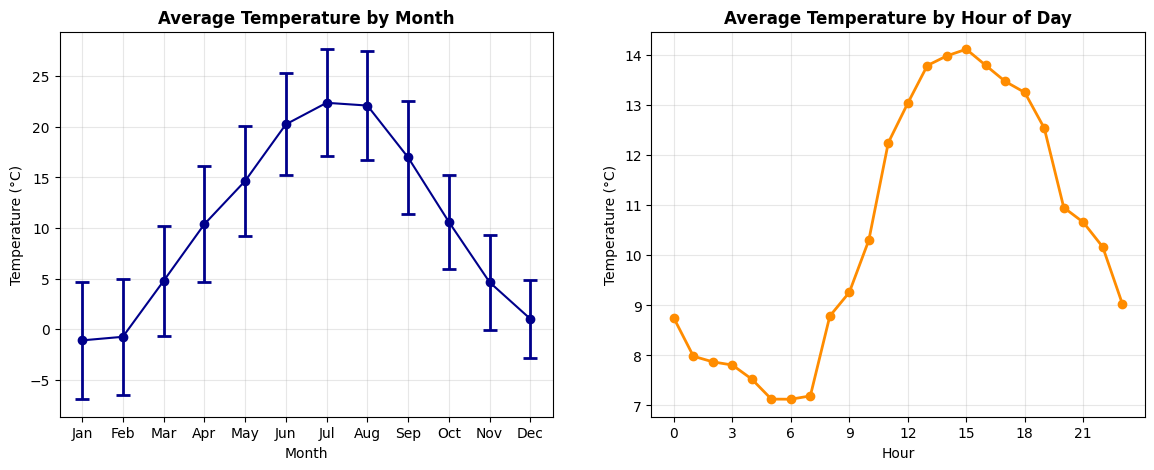

In [ ]:

plt.figure(figsize=(14, 5))

# Subplot 1
plt.subplot(1, 2, 1)
monthly_temp = df_weather.groupby('month')['hour_temp'].agg(['mean', 'std']).reset_index()
plt.errorbar(monthly_temp['month'], monthly_temp['mean'], yerr=monthly_temp['std'],
             fmt='o-', capsize=5, color='darkblue', elinewidth=2, capthick=2)
plt.title('Average Temperature by Month', fontsize=12, fontweight='bold')
plt.xlabel('Month', fontsize=10)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)

# Subplot 2
plt.subplot(1, 2, 2)
hourly_temp = df_weather.groupby('hour')['hour_temp'].mean()
plt.plot(hourly_temp.index, hourly_temp.values, 'o-', color='darkorange', linewidth=2)
plt.title('Average Temperature by Hour of Day', fontsize=12, fontweight='bold')
plt.xlabel('Hour', fontsize=10)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.xticks(range(0, 24, 3))
plt.grid(True, alpha=0.3)




In [ ]:
alarms_hourly = df_alarms.set_index('start').resample('h').size().fillna(0)
alarms_df = alarms_hourly.reset_index()
alarms_df.columns = ['datetime', 'alarms']
alarms_df['hour'] = alarms_df['datetime'].dt.hour
alarms_df['day_type'] = alarms_df['datetime'].dt.dayofweek.apply(lambda x: 'Вихідні' if x >= 5 else 'Будні')

# boxplot
fig = px.box(alarms_df, x='hour', y='alarms', color='day_type',
             color_discrete_map={'Будні': '#3498db', 'Вихідні': '#e74c3c'},
             labels={'hour': 'Година доби', 'alarms': 'Кількість тривог', 'day_type': 'День тижня'},
             title='<b>Розподіл повітряних тривог по годинах доби</b><br><span style="font-size:14px">Будні (сині) vs Вихідні (червоні)</span>')

fig.update_layout(
    height=700,
    width=1200,
    font=dict(size=12),
    boxmode='group',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='black',
        borderwidth=1
    )
)

fig.show()

In [ ]:

alarms_hourly = df_alarms.set_index('start').resample('h').size().fillna(0)
alarms_df = alarms_hourly.reset_index()
alarms_df.columns = ['datetime', 'alarms']
alarms_df['hour'] = alarms_df['datetime'].dt.hour
alarms_df['is_weekend'] = alarms_df['datetime'].dt.dayofweek.isin([5, 6])
alarms_df['day_type'] = alarms_df['is_weekend'].map({True: 'Вихідні', False: 'Будні'})

weekday = alarms_df[alarms_df['day_type'] == 'Будні'].groupby('hour')['alarms'].mean()
weekend = alarms_df[alarms_df['day_type'] == 'Вихідні'].groupby('hour')['alarms'].mean()


fig = go.Figure()
fig.add_trace(go.Scatter(x=weekday.index, y=weekday.values, mode='lines+markers',
                         name='Будні', line=dict(color='#3b82f6', width=3),
                         marker=dict(size=8, symbol='circle')))
fig.add_trace(go.Scatter(x=weekend.index, y=weekend.values, mode='lines+markers',
                         name='Вихідні', line=dict(color='#ef4444', width=3),
                         marker=dict(size=8, symbol='circle')))

fig.update_layout(
    title='<b>Добовий профіль тривог</b><br><span style="font-size:14px">Середня кількість за годину</span>',
    xaxis=dict(title='Година', tickmode='linear', tick0=0, dtick=2, ticktext=[f'{h}:00' for h in range(0, 24, 2)]),
    yaxis=dict(title='Середня кількість тривог'),
    height=600, width=1100, hovermode='x unified',
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.9)')
)
fig.show()

In [ ]:
alarms_hourly = df_alarms.set_index('start').resample('h').size().fillna(0)
alarms_df = alarms_hourly.reset_index()
alarms_df.columns = ['datetime', 'alarms']
alarms_df['day_name'] = alarms_df['datetime'].dt.dayofweek.map({
    0: 'Понеділок', 1: 'Вівторок', 2: 'Середа', 3: 'Четвер',
    4: "П'ятниця", 5: 'Субота', 6: 'Неділя'
})

day_order = ['Понеділок', 'Вівторок', 'Середа', 'Четвер', "П'ятниця", 'Субота', 'Неділя']
daily_avg = alarms_df.groupby('day_name')['alarms'].mean().reindex(day_order)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=daily_avg.index,
    y=daily_avg.values,
    mode='lines+markers',
    name='Середня кількість тривог',
    line=dict(color='#3b82f6', width=3),
    marker=dict(size=10, color='#ef4444', symbol='circle'),
    text=daily_avg.values.round(2),
    textposition='top center',
    hovertemplate='%{x}<br>Середня кількість: %{y:.2f}<extra></extra>'
))

fig.update_layout(
    title='<b>Тижневий профіль тривог</b><br><span style="font-size:14px">Середня кількість тривог за день</span>',
    xaxis=dict(title='День тижня'),
    yaxis=dict(title='Середня кількість тривог'),
    height=550,
    width=900,
    hovermode='x'
)

fig.show()